In [ ]:
#Objective:
The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.

Dataset:
1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
3.	FM - May indicate "Fetal Movements" detected by the monitor.
4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cardiotocographic.csv')
df.head()
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None


In [2]:
for col in ['LB', 'AC', 'DS', 'DP', 'MLTV', 'Width', 'Tendency', 'NSP']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

print(df.isnull().sum())

print('Statistical Summary using describe():')
display(df.describe())

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64
Statistical Summary using describe():


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.214328,0.004370,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734356,42.719161,0.642424,0.641426
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001668,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [ ]:
print('\nMedian for each variable:')
display(df.median().to_frame(name='Median'))


Median for each variable:


,Median
LB,133.000000
AC,0.001668
FM,0.000000
UC,0.004484
DL,0.000000
DS,0.000000
DP,0.000000
ASTV,49.000000
MSTV,1.200000
ALTV,0.000000


### Interesting Findings from Statistical Summary:

*   **Baseline FHR (LB):** The mean and median are relatively close, suggesting a somewhat symmetric distribution. The standard deviation indicates a moderate spread in baseline heart rates.
*   **Accelerations (AC), Decelerations (DL, DS, DP):** These columns show very low mean values and often a median of 0. This suggests that accelerations and decelerations are not constantly present and might be rare events, or that most observations have zero occurrences.
*   **Fetal Movements (FM):** Similar to AC and decelerations, FM also has a low mean and a median of 0, implying that fetal movements might not be frequent across all readings.
*   **Uterine Contractions (UC):** The mean and median are also relatively low, indicating contractions are present but possibly not with high frequency or intensity in the majority of observations.
*   **Variability Measures (ASTV, MSTV, ALTV, MLTV):** These measures, representing short and long-term variability, show a range of values. The difference between min and max, along with standard deviation, can give an idea of how much variability changes across the dataset. For instance, ASTV has a wide range (0-91), indicating significant differences in short-term variability among fetuses.
*   **Width, Tendency, NSP:** These are also numerical. 'Width' has a relatively large range, while 'Tendency' has a smaller range with discrete values (likely categorical or ordinal, but currently treated as numerical).

Further analysis, especially visualizations, would help confirm these initial observations and explore the distribution shapes and potential outliers in more detail.

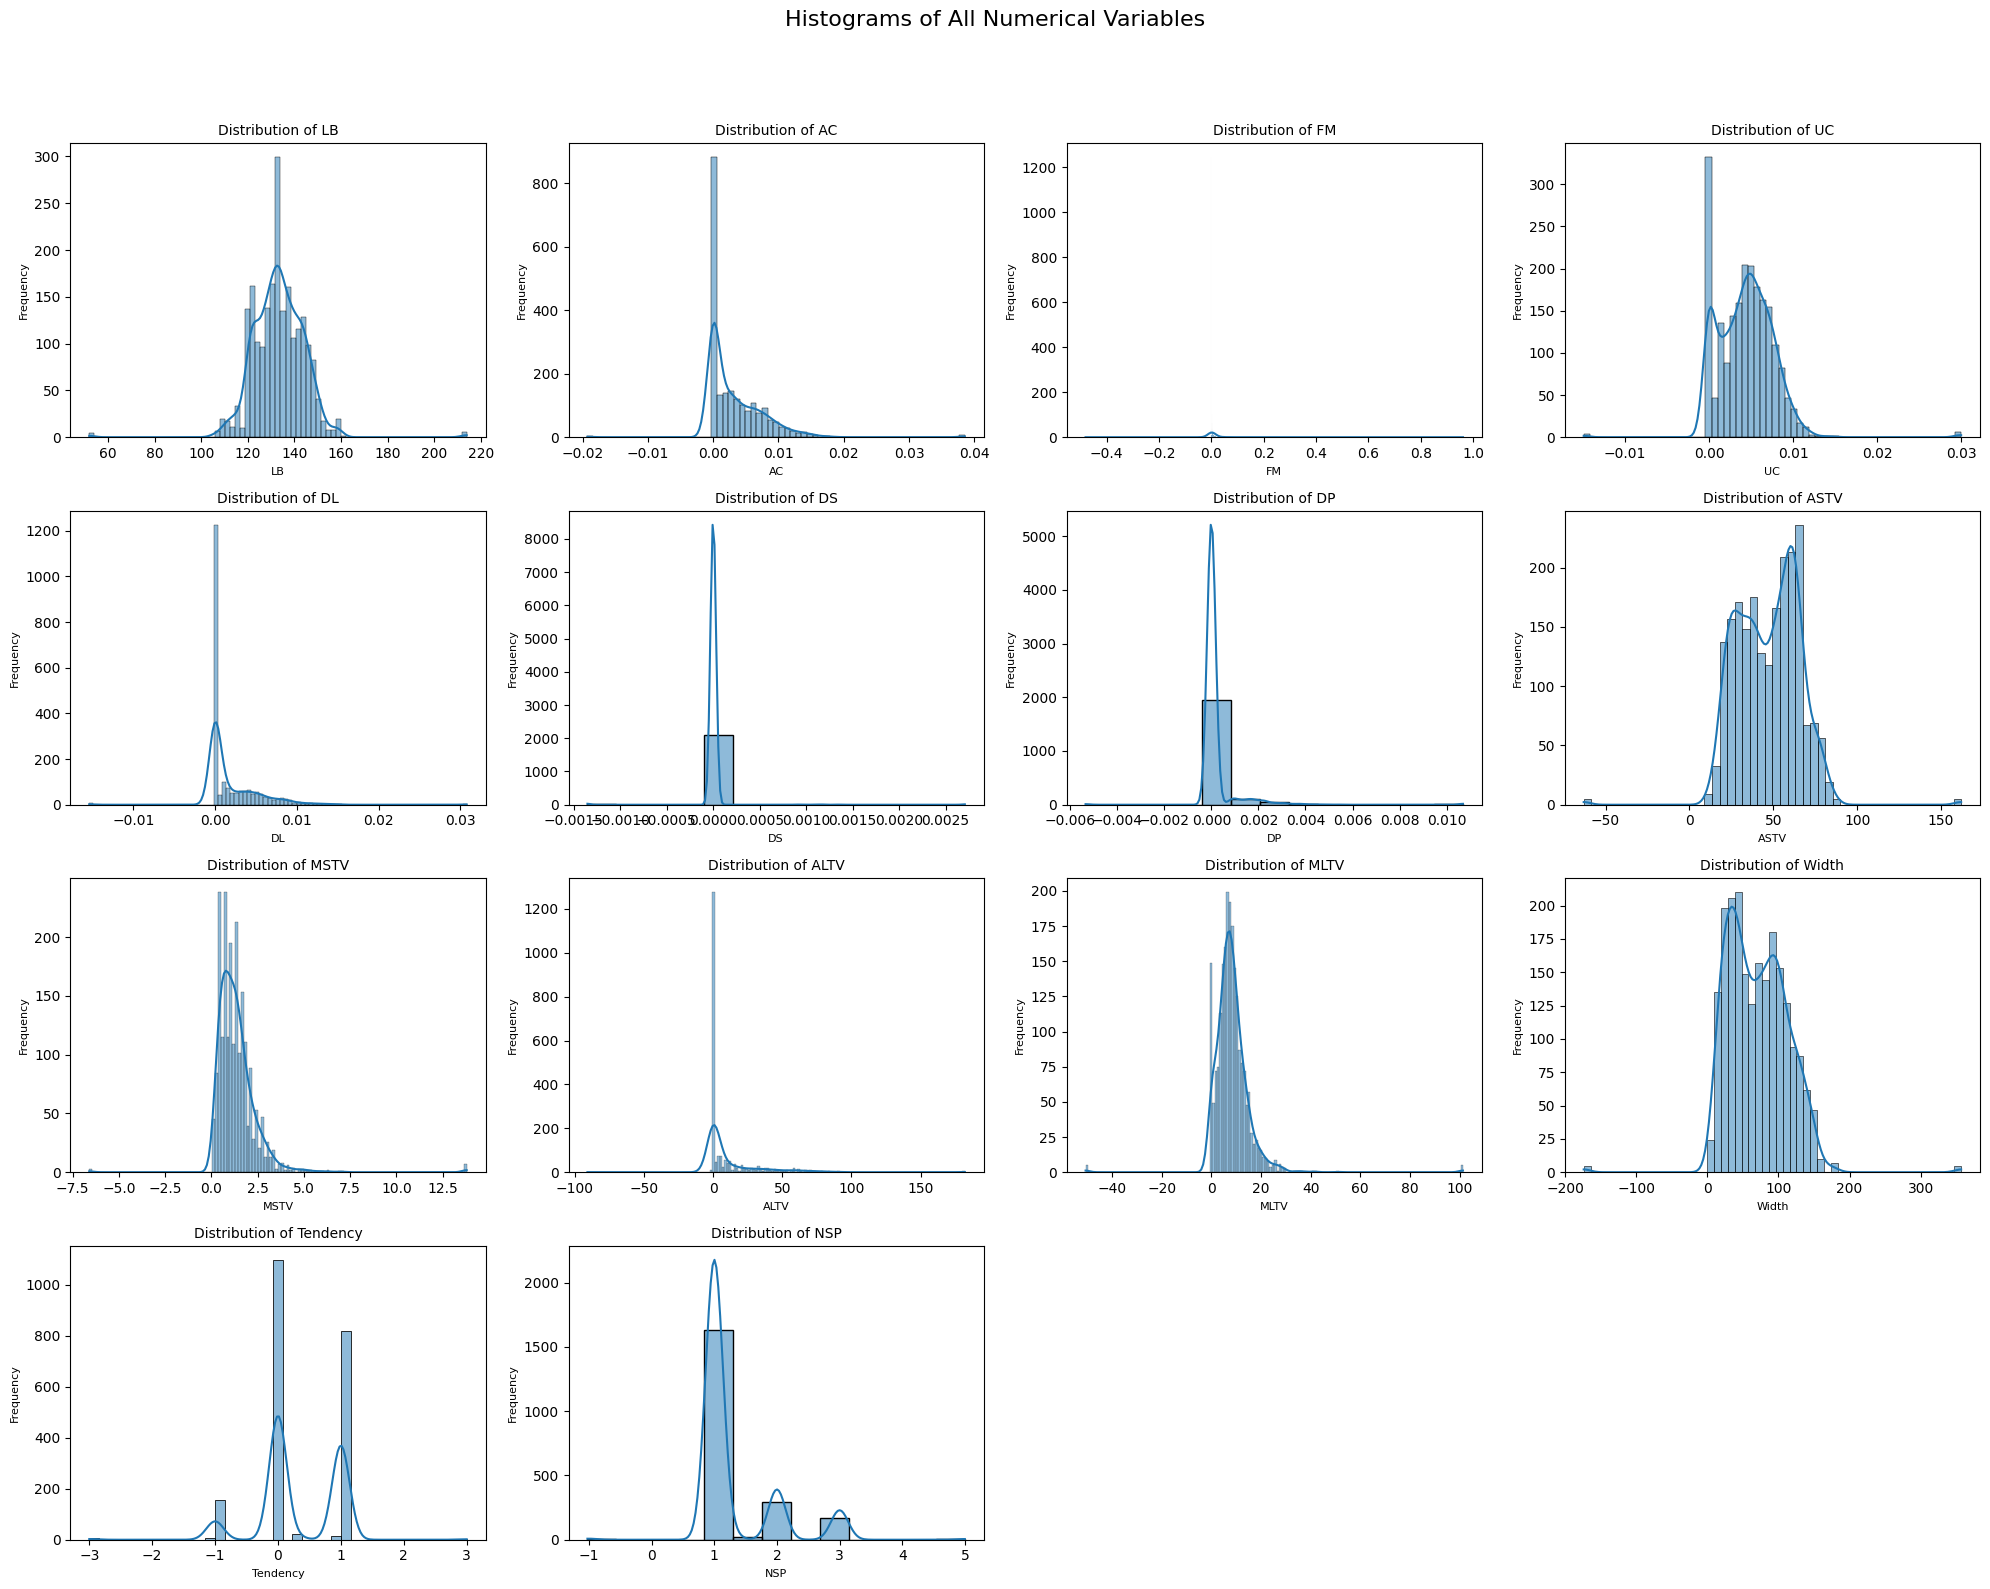

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all column names
columns = df.columns.tolist()

# Determine the number of rows and columns for the subplot grid
n_cols = 4  # Number of columns for the subplots
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically
plt.suptitle('Histograms of All Numerical Variables', y=1.02, fontsize=16)

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1) # Create subplot for each column
    sns.histplot(df[col], kde=True) # Use histplot for histogram with KDE
    plt.title(f'Distribution of {col}', fontsize=10) # Set title for each subplot
    plt.xlabel(col, fontsize=8)
    plt.ylabel('Frequency', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

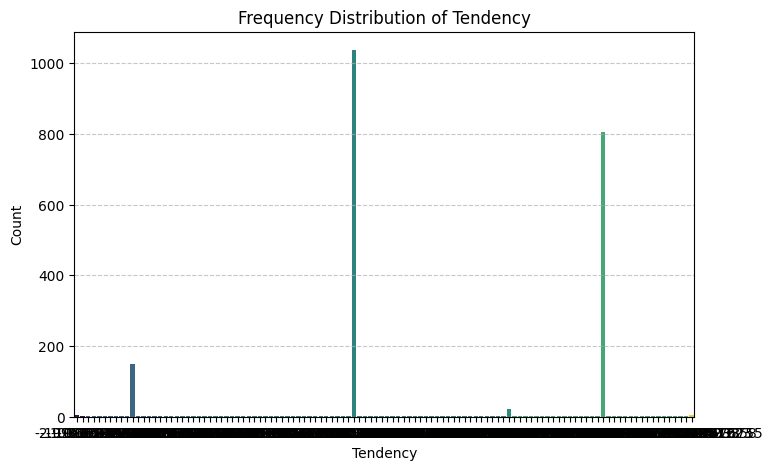

In [4]:
# Bar chart for 'Tendency' (categorical variable)
plt.figure(figsize=(8, 5))
sns.countplot(x='Tendency', data=df, palette='viridis', hue='Tendency', legend=False)
plt.title('Frequency Distribution of Tendency')
plt.xlabel('Tendency')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Correlation Heatmap

Let's visualize the correlation matrix to understand the linear relationships between all numerical variables.

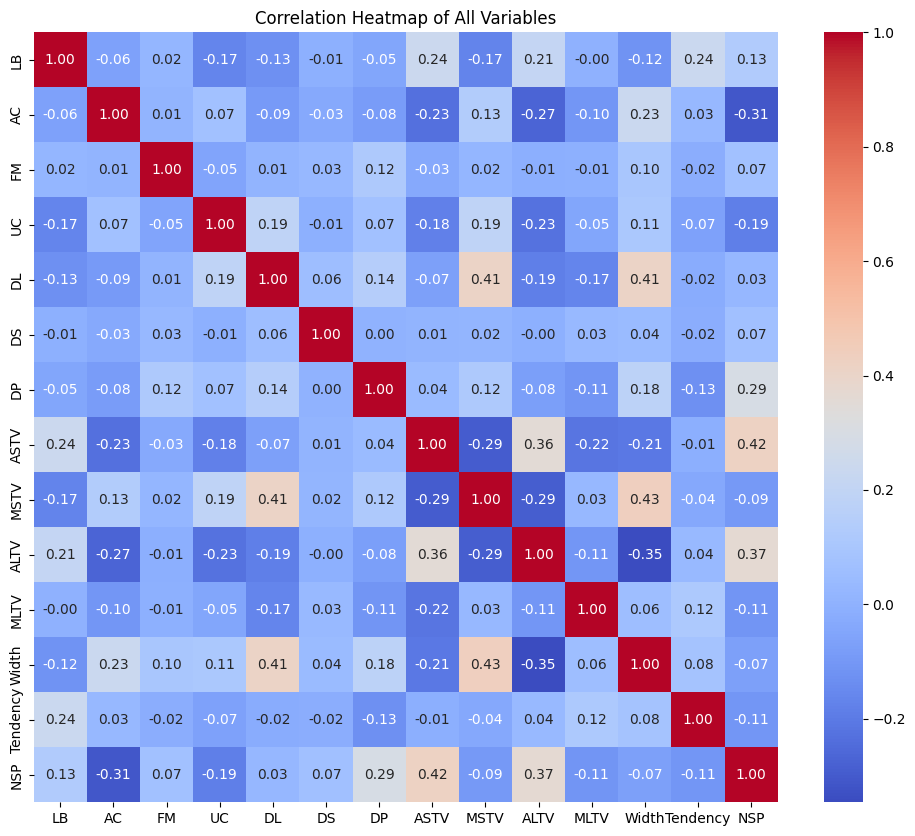

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Variables')
plt.show()

### Pair Plot for Deeper Insights

To explore relationships and distributions for a subset of key variables more deeply, let's create a pair plot. I'll select some representative variables for this.

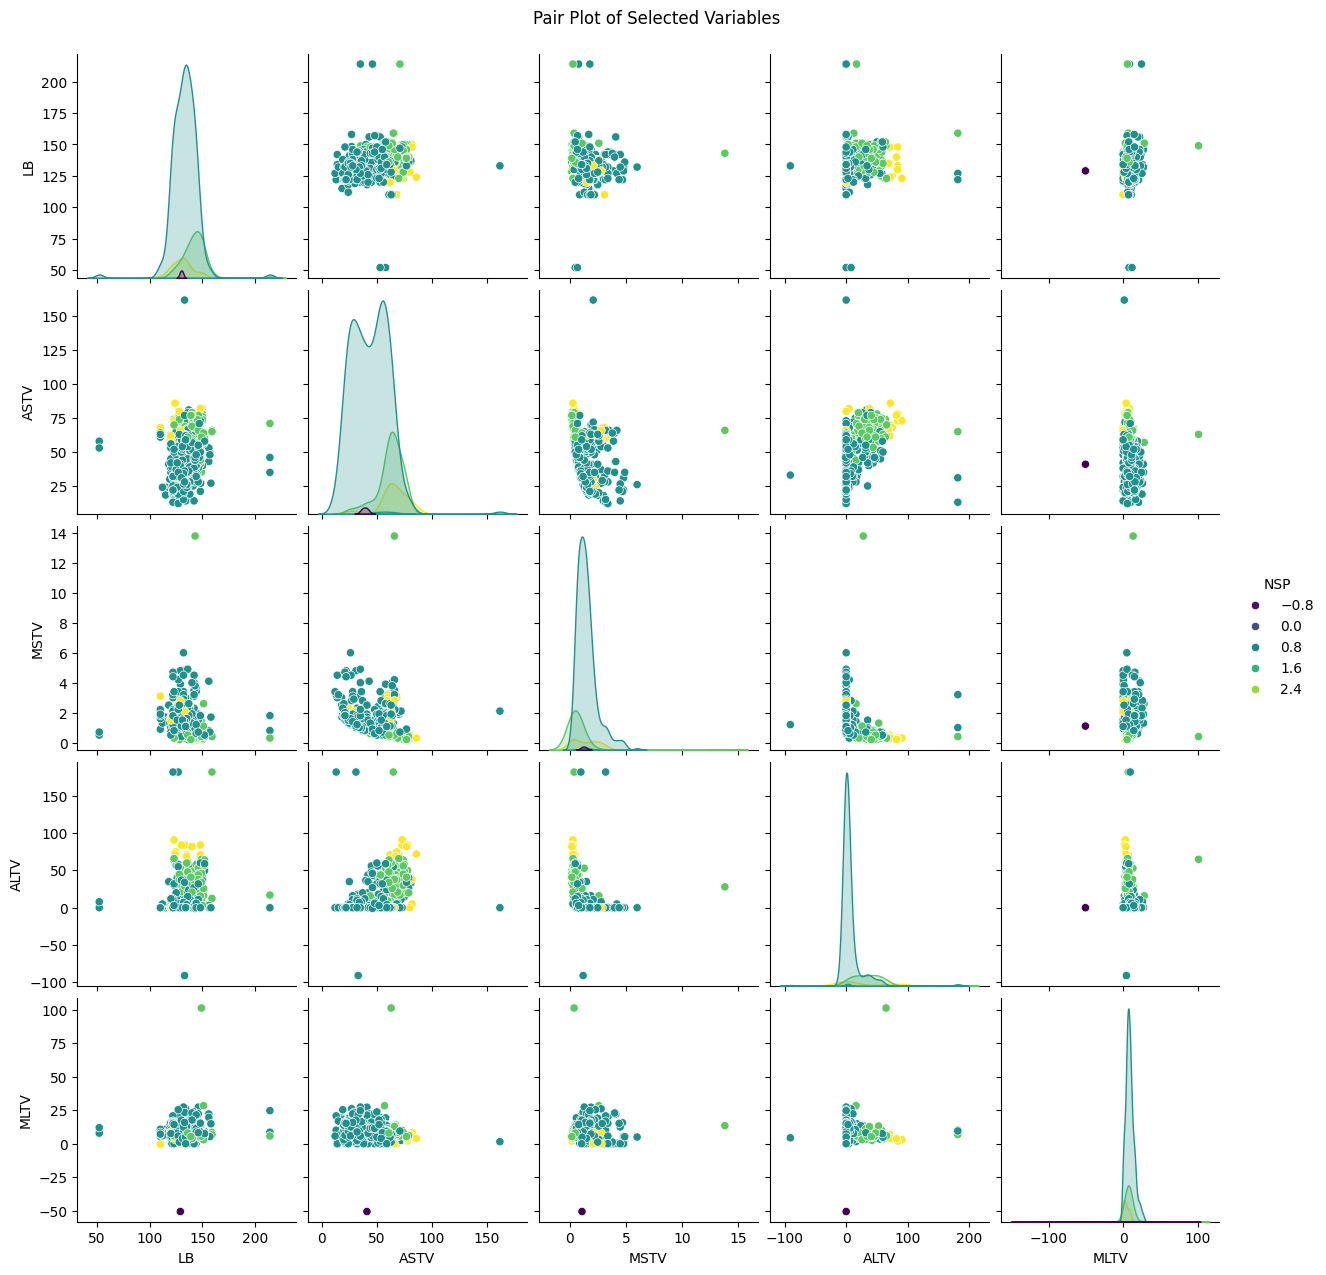

In [6]:
selected_cols_for_pairplot = ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'NSP']
# sns.pairplot(df[selected_cols_for_pairplot], diag_kind='kde')
# To make it more manageable due to large dataset and potentially long run time, let's sample it.

# Sample a subset of the data for the pair plot if the dataset is large
# This helps in reducing computation time for large datasets
if len(df) > 500:
    sampled_df = df.sample(n=500, random_state=42) # Adjust n as needed
else:
    sampled_df = df

sns.pairplot(sampled_df[selected_cols_for_pairplot], diag_kind='kde', hue='NSP', palette='viridis')
plt.suptitle('Pair Plot of Selected Variables', y=1.02) # Adjust suptitle position
plt.show()